# Noise-Model Benchmark

Compare noiseless execution against simple depolarizing, amplitude-damping, readout-error, and combined noise models for representative QML workflows. Classical references are included as non-circuit baselines; the small defaults are benchmark templates, not definitive performance claims.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from io import BytesIO
import base64

from IPython.display import display
import matplotlib.pyplot as plt
from qml.benchmarks import compare_classification_models, compare_regression_models
from qml.noise import build_noise_model, noise_model_tag
from qml.reporting import print_table

In [3]:
CONFIG = {
    "seeds": [0],
    "n_samples": 20,
    "dataset_noise": 0.1,
    "test_size": 0.25,
    "classification_dataset": "moons",
    "regression_dataset": "sine",
}

NOISE_SWEEP = [
    ("noiseless", None),
    ("depolarizing_0.02", build_noise_model(depolarizing=0.02)),
    ("amplitude_damping_0.02", build_noise_model(amplitude_damping=0.02)),
    ("readout_error_0.03", build_noise_model(readout_error=0.03)),
    (
        "combined_low",
        build_noise_model(depolarizing=0.01, amplitude_damping=0.01, readout_error=0.02),
    ),
]

In [4]:
def display_png(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=144, bbox_inches="tight")
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    display({"image/png": encoded}, raw=True)
    plt.close(fig)

def _noiseless_lookup(rows, metric):
    return {row["model"]: row[metric] for row in rows if row["noise_model"] == "noiseless"}


def add_classification_noise_deltas(rows):
    noiseless = _noiseless_lookup(rows, "test_accuracy")
    for row in rows:
        baseline = noiseless.get(row["model"])
        row["accuracy_delta_vs_noiseless"] = (
            0.0 if baseline is None else row["test_accuracy"] - baseline
        )
    return rows


def add_regression_noise_deltas(rows):
    noiseless = _noiseless_lookup(rows, "test_mse")
    for row in rows:
        baseline = noiseless.get(row["model"])
        row["mse_delta_vs_noiseless"] = 0.0 if baseline is None else row["test_mse"] - baseline
    return rows


def classification_rows(label, noise_model, result):
    return [
        {
            "noise_model": label,
            "noise_tag": noise_model_tag(noise_model),
            "model": model,
            "test_accuracy": stats["test_accuracy"]["mean"],
            "ci95_low": stats["test_accuracy"]["ci95_low"],
            "ci95_high": stats["test_accuracy"]["ci95_high"],
            "generalization_gap": stats["generalization_gap"]["mean"],
            "runtime_s": stats["runtime_seconds"]["mean"],
        }
        for model, stats in result["summary"].items()
    ]


def regression_rows(label, noise_model, result):
    return [
        {
            "noise_model": label,
            "noise_tag": noise_model_tag(noise_model),
            "model": model,
            "test_mse": stats["test_mse"]["mean"],
            "ci95_low": stats["test_mse"]["ci95_low"],
            "ci95_high": stats["test_mse"]["ci95_high"],
            "generalization_gap": stats["generalization_gap"]["mean"],
            "runtime_s": stats["runtime_seconds"]["mean"],
        }
        for model, stats in result["summary"].items()
    ]

## Classification Noise Sweep

In [5]:
classification_summary = []

for label, noise_model in NOISE_SWEEP:
    result = compare_classification_models(
        models=["vqc", "quantum_kernel", "svm_classifier"],
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["dataset_noise"],
        test_size=CONFIG["test_size"],
        dataset=CONFIG["classification_dataset"],
        model_kwargs={
            "vqc": {"n_layers": 1, "steps": 3, "noise_model": noise_model},
            "quantum_kernel": {"noise_model": noise_model},
        },
        save=False,
    )
    classification_summary.extend(classification_rows(label, noise_model, result))

classification_summary = add_classification_noise_deltas(classification_summary)
print_table(classification_summary, title="Classification noise-model summary")

Classification noise-model summary
+------------------------+--------------------------------------------------------+----------------+---------------+----------+-----------+--------------------+------------+-----------------------------+
| noise_model            | noise_tag                                              | model          | test_accuracy | ci95_low | ci95_high | generalization_gap | runtime_s  | accuracy_delta_vs_noiseless |
+------------------------+--------------------------------------------------------+----------------+---------------+----------+-----------+--------------------+------------+-----------------------------+
| noiseless              | noiseless                                              | vqc            | 0.6           | 0.6      | 0.6       | 0                  | 0.854189   | 0                           |
| noiseless              | noiseless                                              | quantum_kernel | 0.6           | 0.6      | 0.6       | 0.266667 

## Classification Noise-Degradation Plot

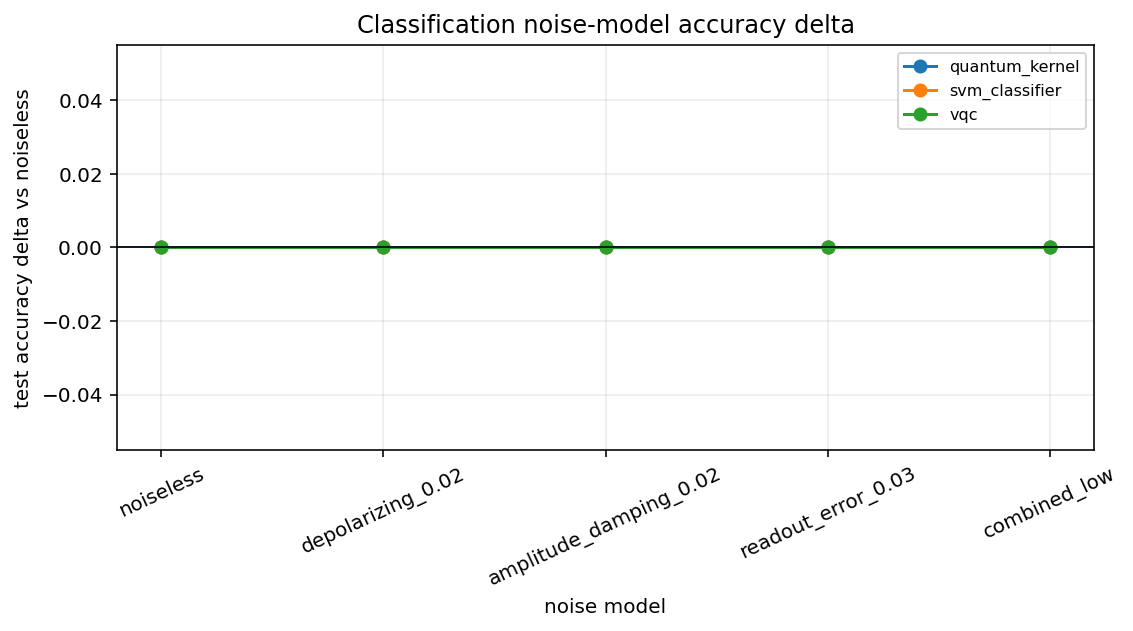

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for model in sorted({row["model"] for row in classification_summary}):
    rows = [row for row in classification_summary if row["model"] == model]
    ax.plot(
        [row["noise_model"] for row in rows],
        [row["accuracy_delta_vs_noiseless"] for row in rows],
        marker="o",
        label=model,
    )
ax.axhline(0.0, color="#111827", linewidth=1)
ax.set_title("Classification noise-model accuracy delta")
ax.set_ylabel("test accuracy delta vs noiseless")
ax.set_xlabel("noise model")
ax.tick_params(axis="x", rotation=25)
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
display_png(fig)

## Regression Noise Sweep

In [7]:
regression_summary = []

for label, noise_model in NOISE_SWEEP:
    result = compare_regression_models(
        models=["vqr", "quantum_kernel_regressor", "ridge_regression"],
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["dataset_noise"],
        test_size=CONFIG["test_size"],
        dataset=CONFIG["regression_dataset"],
        model_kwargs={
            "vqr": {"n_layers": 1, "steps": 4, "noise_model": noise_model},
            "quantum_kernel_regressor": {"noise_model": noise_model},
        },
        save=False,
    )
    regression_summary.extend(regression_rows(label, noise_model, result))

regression_summary = add_regression_noise_deltas(regression_summary)
print_table(regression_summary, title="Regression noise-model summary")

Regression noise-model summary
+------------------------+--------------------------------------------------------+--------------------------+----------+----------+-----------+--------------------+------------+------------------------+
| noise_model            | noise_tag                                              | model                    | test_mse | ci95_low | ci95_high | generalization_gap | runtime_s  | mse_delta_vs_noiseless |
+------------------------+--------------------------------------------------------+--------------------------+----------+----------+-----------+--------------------+------------+------------------------+
| noiseless              | noiseless                                              | vqr                      | 5.08599  | 5.08599  | 5.08599   | 4.35799            | 0.567244   | 0                      |
| noiseless              | noiseless                                              | quantum_kernel_regressor | 2.49846  | 2.49846  | 2.49846   | 2.225   

## Regression Noise-Degradation Plot

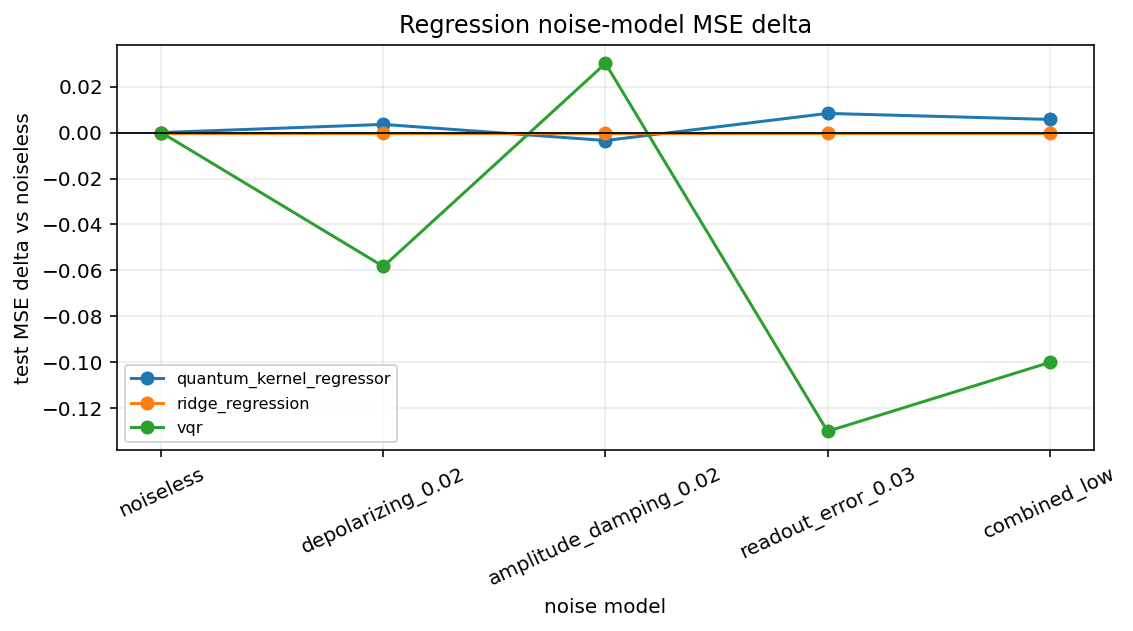

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for model in sorted({row["model"] for row in regression_summary}):
    rows = [row for row in regression_summary if row["model"] == model]
    ax.plot(
        [row["noise_model"] for row in rows],
        [row["mse_delta_vs_noiseless"] for row in rows],
        marker="o",
        label=model,
    )
ax.axhline(0.0, color="#111827", linewidth=1)
ax.set_title("Regression noise-model MSE delta")
ax.set_ylabel("test MSE delta vs noiseless")
ax.set_xlabel("noise model")
ax.tick_params(axis="x", rotation=25)
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
display_png(fig)

## Validation

In [9]:
validation = {
    "classification_rows": len(classification_summary),
    "regression_rows": len(regression_summary),
    "noise_models": len(NOISE_SWEEP),
    "passed": bool(classification_summary and regression_summary),
}
print_table([validation], title="Noise benchmark validation")

Noise benchmark validation
+---------------------+-----------------+--------------+--------+
| classification_rows | regression_rows | noise_models | passed |
+---------------------+-----------------+--------------+--------+
| 15                  | 15              | 5            | True   |
+---------------------+-----------------+--------------+--------+

